In [41]:
# importing the tools
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA# Principle component Analysis

In [42]:
from sklearn.datasets import make_blobs
# 1. Create a complex dataset with 10 features
X_high_dim, _ = make_blobs(n_samples=500, centers=4, n_features=10, random_state=42)

# Let's load this into a Pandas DataFrame so we can visually inspect what high dimensional data looks like
feature_names = [f"Feature_{i+1}" for i in range(10)]
df = pd.DataFrame(X_high_dim, columns=feature_names)

print("============================== BEFORE PCA ==============================")
print(f"Data Shape: {df.shape}")
print("Look at all these columns! We cannot plot a 10-dimensional graph to see the clusters.\n")
display(df.head())

============================== BEFORE PCA ==============================
Data Shape: (500, 10)
Look at all these columns! We cannot plot a 10-dimensional graph to see the clusters.



,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,-8.399397,10.106501,7.000301,-4.683068,-6.390022,-7.213784,-4.078222,-0.249774,-2.036278,-4.319936
1,1.305743,-6.036129,-8.732893,7.382955,9.733340,5.590026,-3.026578,-8.045232,4.080082,-2.154519
2,-8.849500,10.013565,5.713414,-4.667236,-6.899464,-5.523852,-3.547868,2.333312,-1.584566,-4.524734
3,2.497500,-7.748965,-5.165662,-4.635389,-0.528950,4.138716,-5.911180,0.021241,2.527434,-9.373037
4,2.948741,-8.448854,-8.653477,9.536047,11.169288,5.686181,-3.583266,-9.850421,1.292704,-0.352176


In [43]:
# Always sclae the data before Principle component analysis
scaler=MinMaxScaler()
df=scaler.fit_transform(df)

pc_analysis=PCA(n_components=2)
df=pc_analysis.fit_transform(df)

df=pd.DataFrame(df,columns=["Principle Component 1","Principle Component 2"])


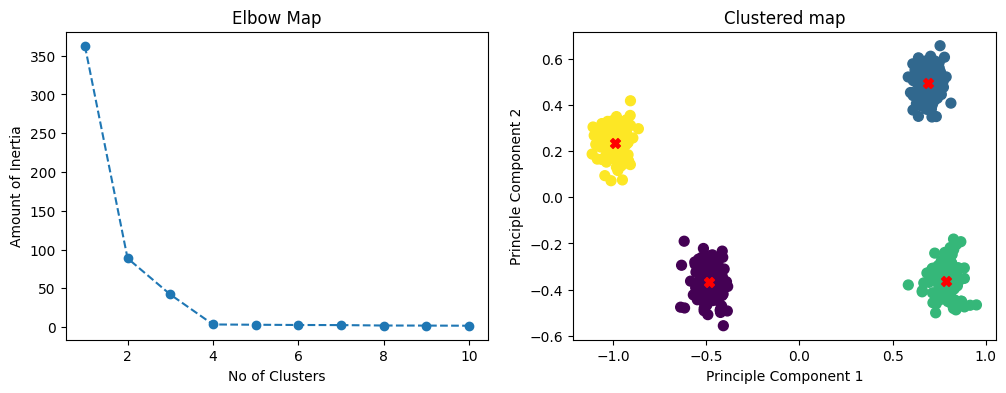

In [44]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++",random_state=42)
    kmeans.fit(df)
    inertia=kmeans.inertia_
    wcss.append(inertia)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(range(1,11),wcss,marker="o",linestyle="--")
plt.xlabel("No of Clusters")
plt.ylabel("Amount of Inertia")
plt.title("Elbow Map")

# taking k as 4
model=KMeans(n_clusters=4,init="k-means++",random_state=42)
model.fit(df)
centers=model.cluster_centers_
label=model.predict(df)
plt.subplot(1,2,2)
plt.scatter(df["Principle Component 1"],df["Principle Component 2"],c=label,marker="o",s=50)
plt.xlabel("Principle Component 1")
plt.ylabel("Principle Component 2")
plt.scatter(centers[:,0],centers[:,1],marker="X",c="red",s=50)
plt.title("Clustered map")
plt.show()